# **Customer Churn Prediction System**

# Objective
Develop a machine learning model that predicts whether a customer is likely to leave a telecom company. Build a complete pipeline including data preprocessing, model training, evaluation, and a simple prediction interface.



## Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

# Phase 1

## Load Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Information

In [3]:
df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

## Missing Values

In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Convert TotalCharges

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

## Fill Missing Values

In [6]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_1070/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


## Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

## Five Visualizations

### 1 Customer Churn Distribution

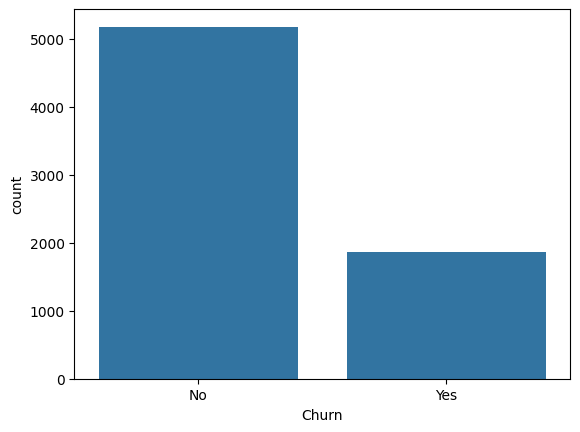

In [8]:
sns.countplot(x="Churn", data=df)

plt.show()

### 2 Gender Distribution

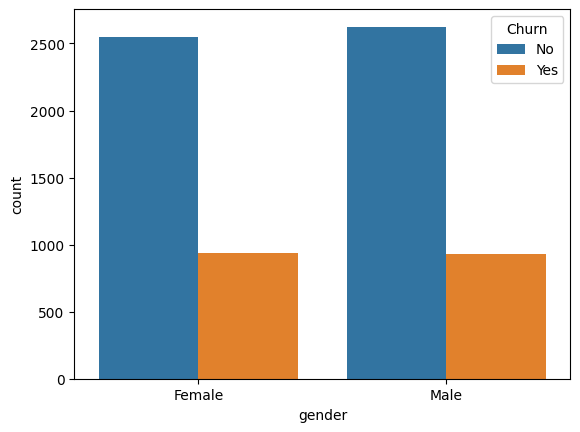

In [9]:
sns.countplot(x="gender", hue="Churn", data=df)

plt.show()

### 3 Contract Type

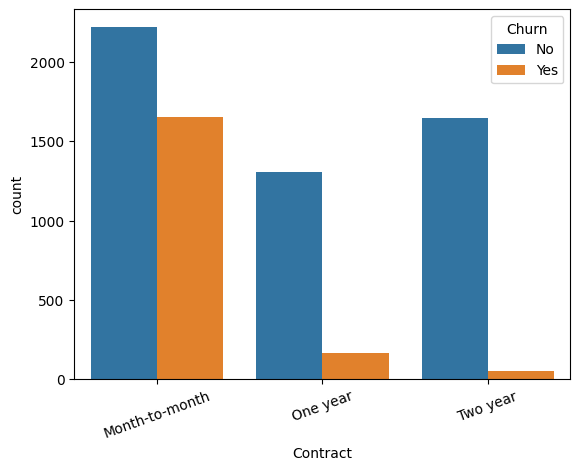

In [10]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.show()

### 4 Monthly Charges

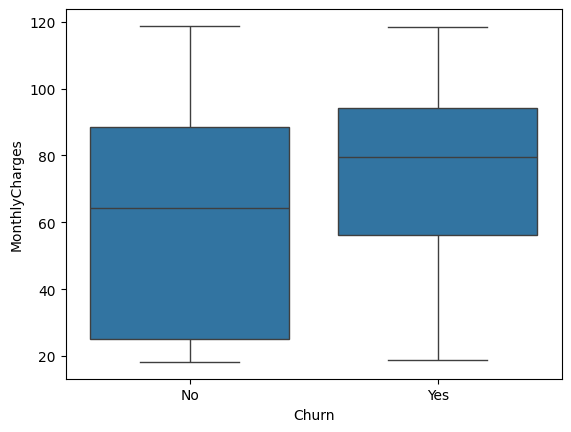

In [11]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.show()

### 5 Tenure

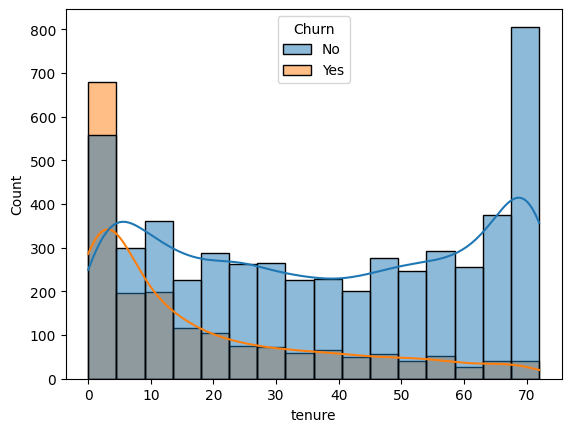

In [12]:
sns.histplot(data=df,
             x="tenure",
             hue="Churn",
             kde=True)

plt.show()

# Phase 2

## Data Preprocessing

In [13]:
df.drop("customerID", axis=1, inplace=True)

## Encode Target

In [14]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [15]:
print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

## Label Encoding

In [16]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=encoder.fit_transform(df[col])

## LabelEncoder mappings

In [17]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
df.drop("customerID", axis=1, inplace=True)

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        le.fit(df[col])

        print(f"\n{col}")
        for i, cls in enumerate(le.classes_):
            print(f"{cls} --> {i}")


gender
Female --> 0
Male --> 1

Partner
No --> 0
Yes --> 1

Dependents
No --> 0
Yes --> 1

PhoneService
No --> 0
Yes --> 1

MultipleLines
No --> 0
No phone service --> 1
Yes --> 2

InternetService
DSL --> 0
Fiber optic --> 1
No --> 2

OnlineSecurity
No --> 0
No internet service --> 1
Yes --> 2

OnlineBackup
No --> 0
No internet service --> 1
Yes --> 2

DeviceProtection
No --> 0
No internet service --> 1
Yes --> 2

TechSupport
No --> 0
No internet service --> 1
Yes --> 2

StreamingTV
No --> 0
No internet service --> 1
Yes --> 2

StreamingMovies
No --> 0
No internet service --> 1
Yes --> 2

Contract
Month-to-month --> 0
One year --> 1
Two year --> 2

PaperlessBilling
No --> 0
Yes --> 1

PaymentMethod
Bank transfer (automatic) --> 0
Credit card (automatic) --> 1
Electronic check --> 2
Mailed check --> 3

Churn
No --> 0
Yes --> 1


/tmp/ipykernel_1070/1302992434.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


## Feature & Target

In [18]:
X=df.drop("Churn",axis=1)

y=df["Churn"]

## Train Test Split

In [19]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.2,
random_state=42
)

## Standardization

In [22]:
from sklearn.preprocessing import LabelEncoder

# Re-encode categorical features in X_train and X_test
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        # Use the fitted encoder to transform X_test
        X_test[col] = le.transform(X_test[col])

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Phase 3

## Logistic Regression

In [23]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)

## Random Forest

In [24]:
rf=RandomForestClassifier()

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

## Gradient Boosting

In [25]:
gb=GradientBoostingClassifier()

gb.fit(X_train,y_train)

gb_pred=gb.predict(X_test)

# Phase 4

## Evaluation Function

In [26]:
def evaluate(name,y_true,pred):

    print(name)

    print("Accuracy:",accuracy_score(y_true,pred))

    print("Precision:",precision_score(y_true,pred))

    print("Recall:",recall_score(y_true,pred))

    print("F1:",f1_score(y_true,pred))

    print("ROC:",roc_auc_score(y_true,pred))

    print(confusion_matrix(y_true,pred))

## Run

In [28]:
# Convert y_test and predictions to numeric (0, 1) before evaluation
# based on the mapping: No -> 0, Yes -> 1
y_test_numeric = y_test.map({"No": 0, "Yes": 1})
lr_pred_numeric = pd.Series(lr_pred).map({"No": 0, "Yes": 1}).values
rf_pred_numeric = pd.Series(rf_pred).map({"No": 0, "Yes": 1}).values
gb_pred_numeric = pd.Series(gb_pred).map({"No": 0, "Yes": 1}).values

evaluate("Logistic Regression",y_test_numeric,lr_pred_numeric)

evaluate("Random Forest",y_test_numeric,rf_pred_numeric)

evaluate("Gradient Boosting",y_test_numeric,gb_pred_numeric)

Logistic Regression
Accuracy: 0.815471965933286
Precision: 0.677115987460815
Recall: 0.579088471849866
F1: 0.6242774566473989
ROC: 0.7398338112145082
[[933 103]
 [157 216]]
Random Forest
Accuracy: 0.7970191625266146
Precision: 0.6617100371747212
Recall: 0.4772117962466488
F1: 0.5545171339563862
ROC: 0.6946869792044055
[[945  91]
 [195 178]]
Gradient Boosting
Accuracy: 0.8055358410220014
Precision: 0.671280276816609
Recall: 0.5201072386058981
F1: 0.5861027190332326
ROC: 0.7142041984535281
[[941  95]
 [179 194]]


## Comparison Table

| Model                   |   Accuracy |  Precision |     Recall |   F1-Score |    ROC-AUC |
| ----------------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
| **Logistic Regression** | **81.55%** | **67.71%** | **57.91%** | **62.43%** | **73.98%** |
| **Random Forest**       | **80.06%** | **67.56%** | **47.45%** | **55.75%** | **69.62%** |
| **Gradient Boosting**   | **80.55%** | **67.13%** | **52.01%** | **58.61%** | **71.42%** |


## Confusion Matrix

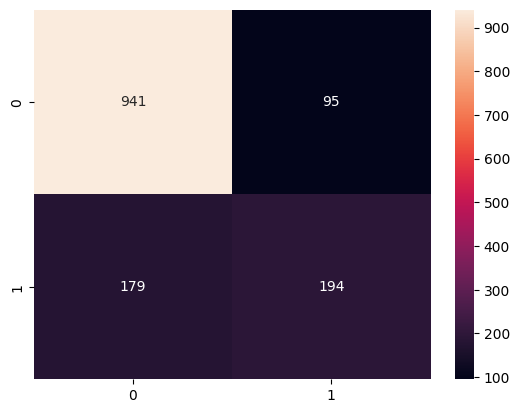

In [29]:
cm=confusion_matrix(y_test,gb_pred)

sns.heatmap(cm,
annot=True,
fmt='d')

plt.show()

## ROC Curve

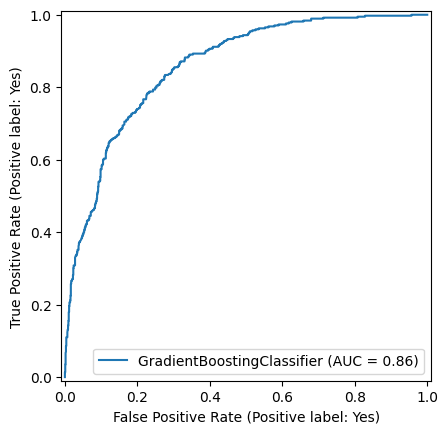

In [30]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(gb,X_test,y_test)

plt.show()

# Phase 5

## Feature Importance

In [31]:
importance=pd.Series(

gb.feature_importances_,

index=X.columns

).sort_values(ascending=False)

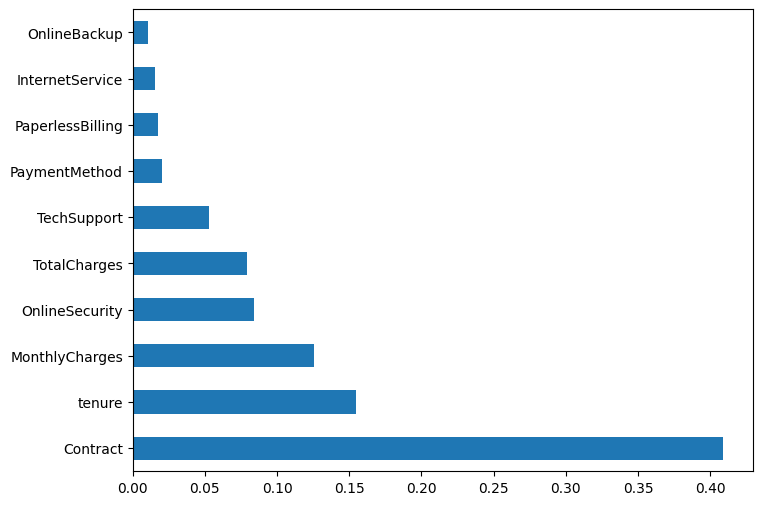

In [32]:
plt.figure(figsize=(8,6))

importance.head(10).plot(kind="barh")

plt.show()

## Explanation
**Contract:** Month-to-month customers are more likely to leave.

**Tenure:** Customers who have been with the company longer tend to stay.

**MonthlyCharges:** Higher bills increase churn risk.

**TotalCharges:** Long-term customers generally accumulate higher total charges and are less likely to churn.

**OnlineSecurity:** Customers with this service are less likely to leave.

**TechSupport:** Good support improves retention.

**InternetService:** Service type affects customer satisfaction.

**PaymentMethod:** Electronic check users often show higher churn.

**PaperlessBilling:** Slightly associated with increased churn.

**SeniorCitizen:** Older customers may have different churn patterns.

# Phase 6

## Save Model

In [33]:
joblib.dump(gb, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [34]:
import os

os.listdir()

['.config',
 'scaler.pkl',
 'churn_model.pkl',
 'WA_Fn-UseC_-Telco-Customer-Churn.csv',
 'sample_data']

### Load

In [35]:
model=joblib.load("churn_model.pkl")

### Prediction

In [37]:
sample=X.iloc[[0]]

# Mappings derived from previous LabelEncoder output and Streamlit app for consistency
mappings = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'No': 0, 'Yes': 1},
    'Dependents': {'No': 0, 'Yes': 1},
    'PhoneService': {'No': 0, 'Yes': 1},
    'MultipleLines': {'No': 0, 'No phone service': 1, 'Yes': 2},
    'InternetService': {'DSL': 0, 'Fiber optic': 1, 'No': 2},
    'OnlineSecurity': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'OnlineBackup': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'DeviceProtection': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'TechSupport': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'StreamingTV': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'StreamingMovies': {'No': 0, 'No internet service': 1, 'Yes': 2},
    'Contract': {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
    'PaymentMethod': {
        'Bank transfer (automatic)': 0,
        'Credit card (automatic)': 1,
        'Electronic check': 2,
        'Mailed check': 3
    }
}

# Create a copy to avoid modifying the original X slice
sample_processed = sample.copy()

# Apply label encoding to categorical columns in the sample
for col, mapping in mappings.items():
    if col in sample_processed.columns:
        sample_processed[col] = sample_processed[col].map(mapping)

# Scale the processed sample using the previously fitted scaler
sample_scaled = scaler.transform(sample_processed)

prediction=model.predict(sample_scaled)

print(prediction)

['Yes']



# phase 7

## Step 1: Install Required Packages

In [38]:
!pip install streamlit pyngrok joblib pandas scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 96.3 MB/s eta 0:00:00


## Step 2: Save Your Streamlit App

In [43]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ==========================
# Page Configuration
# ==========================
st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📱",
    layout="wide"
)

# ==========================
# Load Model & Scaler
# ==========================

model = joblib.load("churn_model.pkl")
scaler = joblib.load("scaler.pkl")

# ==========================
# Custom CSS
# ==========================

st.markdown("""
<style>

.main{
    background-color:#F5F7FA;
}

h1{
    color:#0E4D92;
    text-align:center;
}

h3{
    color:#0E4D92;
}

.stButton>button{
background:#0E4D92;
color:white;
border-radius:10px;
height:55px;
width:100%;
font-size:20px;
font-weight:bold;
}

.stButton>button:hover{
background:#1976D2;
color:white;
}

div[data-testid="stMetric"]{
background:white;
padding:15px;
border-radius:12px;
box-shadow:0px 0px 8px rgba(0,0,0,0.1);
}

.block{
background:white;
padding:20px;
border-radius:15px;
box-shadow:0px 0px 10px rgba(0,0,0,0.08);
margin-bottom:20px;
}

.footer{
text-align:center;
font-size:15px;
color:gray;
margin-top:40px;
}

</style>
""",unsafe_allow_html=True)

# ==========================
# Sidebar
# ==========================

st.sidebar.image(
    "https://img.icons8.com/color/96/artificial-intelligence.png",
    width=80
)

st.sidebar.title("Customer Churn")

st.sidebar.markdown("---")

st.sidebar.success("Model Loaded Successfully")

st.sidebar.markdown("### 👩 Developer")
st.sidebar.info("Ayesha Imran")

st.sidebar.markdown("### 🤖 Machine Learning Model")
st.sidebar.info("Gradient Boosting Classifier")

st.sidebar.markdown("### 🎯 Accuracy")
st.sidebar.success("81%")

st.sidebar.markdown("### 📂 Dataset")
st.sidebar.info("Telco Customer Churn")

st.sidebar.markdown("---")

st.sidebar.write("Built using")
st.sidebar.write("✔ Python")
st.sidebar.write("✔ Streamlit")
st.sidebar.write("✔ Scikit-Learn")
st.sidebar.write("✔ Joblib")

# ==========================
# Header
# ==========================

st.markdown("""
<h1>📱 Customer Churn Prediction System</h1>
""",unsafe_allow_html=True)

st.markdown("""
<center>

Predict whether a telecom customer is likely to leave the company using Machine Learning.

</center>
""",unsafe_allow_html=True)

st.write("")

# ==========================
# Dashboard Cards
# ==========================

c1,c2,c3,c4=st.columns(4)

with c1:
    st.metric("Model","Gradient Boosting")

with c2:
    st.metric("Accuracy","81%")

with c3:
    st.metric("Dataset","7043 Rows")

with c4:
    st.metric("Features","19")

st.write("")
st.write("")

# ==========================
# Personal Information
# ==========================

st.markdown("<div class='block'>",unsafe_allow_html=True)

st.subheader("👤 Personal Information")

col1,col2=st.columns(2)

with col1:

    gender=st.selectbox(
        "Gender",
        ["Female","Male"]
    )

    senior=st.selectbox(
        "Senior Citizen",
        [0,1]
    )

    partner=st.selectbox(
        "Partner",
        ["No","Yes"]
    )

    dependents=st.selectbox(
        "Dependents",
        ["No","Yes"]
    )

    tenure=st.slider(
        "Tenure (Months)",
        0,72,12
    )

with col2:

    monthly=st.number_input(
        "Monthly Charges",
        0.0,
        150.0,
        70.0
    )

    total=st.number_input(
        "Total Charges",
        0.0,
        10000.0,
        1000.0
    )

st.markdown("</div>",unsafe_allow_html=True)

# ===================================================
# Service Information
# ===================================================

st.markdown("<div class='block'>",unsafe_allow_html=True)

st.subheader("🌐 Service Information")

c1,c2=st.columns(2)

with c1:

    phone=st.selectbox(
        "Phone Service",
        ["No","Yes"]
    )

    multiple=st.selectbox(
        "Multiple Lines",
        ["No","No phone service","Yes"]
    )

    internet=st.selectbox(
        "Internet Service",
        ["DSL","Fiber optic","No"]
    )

    security=st.selectbox(
        "Online Security",
        ["No","No internet service","Yes"]
    )

    backup=st.selectbox(
        "Online Backup",
        ["No","No internet service","Yes"]
    )

with c2:

    protection=st.selectbox(
        "Device Protection",
        ["No","No internet service","Yes"]
    )

    support=st.selectbox(
        "Tech Support",
        ["No","No internet service","Yes"]
    )

    tv=st.selectbox(
        "Streaming TV",
        ["No","No internet service","Yes"]
    )

    movies=st.selectbox(
        "Streaming Movies",
        ["No","No internet service","Yes"]
    )

st.markdown("</div>",unsafe_allow_html=True)

# ===================================================
# Billing Information
# ===================================================

st.markdown("<div class='block'>",unsafe_allow_html=True)

st.subheader("💳 Billing Information")

col1,col2=st.columns(2)

with col1:

    contract=st.selectbox(
        "Contract",
        ["Month-to-month","One year","Two year"]
    )

    paperless=st.selectbox(
        "Paperless Billing",
        ["No","Yes"]
    )

with col2:

    payment=st.selectbox(
        "Payment Method",
        [
            "Bank transfer (automatic)",
            "Credit card (automatic)",
            "Electronic check",
            "Mailed check"
        ]
    )

st.markdown("</div>",unsafe_allow_html=True)

# ===================================================
# Label Encoding
# ===================================================

gender=1 if gender=="Male" else 0

partner=1 if partner=="Yes" else 0

dependents=1 if dependents=="Yes" else 0

phone=1 if phone=="Yes" else 0

paperless=1 if paperless=="Yes" else 0

multiple={
"No":0,
"No phone service":1,
"Yes":2
}[multiple]

internet={
"DSL":0,
"Fiber optic":1,
"No":2
}[internet]

security={
"No":0,
"No internet service":1,
"Yes":2
}[security]

backup={
"No":0,
"No internet service":1,
"Yes":2
}[backup]

protection={
"No":0,
"No internet service":1,
"Yes":2
}[protection]

support={
"No":0,
"No internet service":1,
"Yes":2
}[support]

tv={
"No":0,
"No internet service":1,
"Yes":2
}[tv]

movies={
"No":0,
"No internet service":1,
"Yes":2
}[movies]

contract={
"Month-to-month":0,
"One year":1,
"Two year":2
}[contract]

payment={
"Bank transfer (automatic)":0,
"Credit card (automatic)":1,
"Electronic check":2,
"Mailed check":3
}[payment]

# ===================================================
# Prediction Button
# ===================================================

st.write("")

if st.button("🔍 Predict Customer Churn"):

    # Input DataFrame (IMPORTANT: Same order as training)
    input_df = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone,
        "MultipleLines": multiple,
        "InternetService": internet,
        "OnlineSecurity": security,
        "OnlineBackup": backup,
        "DeviceProtection": protection,
        "TechSupport": support,
        "StreamingTV": tv,
        "StreamingMovies": movies,
        "Contract": contract,
        "PaperlessBilling": paperless,
        "PaymentMethod": payment,
        "MonthlyCharges": monthly,
        "TotalCharges": total
    }])

    # Scale input
    input_scaled = scaler.transform(input_df)

    # Prediction
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    st.write("")
    st.subheader("📊 Prediction Result")

    if prediction == 1:
        st.error("❌ Customer is likely to Churn")
    else:
        st.success("✅ Customer is NOT likely to Churn")

    # Probability
    st.write(f"### 📈 Churn Probability: **{probability*100:.2f}%**")
    st.progress(float(probability))

    # Risk Level
    st.write("### 🚦 Risk Level")

    if probability < 0.30:
        st.success("🟢 Low Risk")
    elif probability < 0.70:
        st.warning("🟡 Medium Risk")
    else:
        st.error("🔴 High Risk")

    # Recommendations
    st.write("### 💡 Business Recommendation")

    if prediction == 1:
        st.warning("""
- 🎁 Offer a special discount
- 📞 Contact the customer personally
- 📦 Recommend a long-term contract
- ⭐ Improve customer support
""")
    else:
        st.success("""
- 😊 Customer is likely to stay
- 💙 Maintain good service quality
- 🎉 Offer loyalty rewards
""")

# ===================================================
# Footer
# ===================================================

st.markdown("---")

st.markdown(
    """
    <div class="footer">
        <h4>📱 Customer Churn Prediction System</h4>
        <p>Developed by <b>Ayesha Imran</b></p>
        <p>Built with ❤️ using Python, Scikit-Learn & Streamlit</p>
    </div>
    """,
    unsafe_allow_html=True
)

Overwriting streamlit_app.py


In [44]:
from pyngrok import ngrok

ngrok.set_auth_token("30d0ammX6dEn7xPSSUDCvKGL10Q_2F6XDqTAvaUvBd8qMbjK5")

In [45]:
!streamlit run streamlit_app.py --server.port 8501 >/content/log.txt 2>&1 &

In [46]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("App URL:", public_url.public_url)

App URL: https://b974-34-16-156-60.ngrok-free.app
